# Real vs. every method, scatter plots, all benchmarks

One `scatter_vs_real`-style plot per method (ALPS, RS-Grad, RS-MCMC, MCMC, Evolutionary) against the real program, for every benchmark -- matching `results.ipynb`'s own `for method in methods: scatter_vs_real(...)` pattern. 2D always; 3D additionally for benchmarks with more than 2 variables (first 3 variables shown).

In [1]:
import sys, json, os
sys.path.insert(0, ".")
from aggregate_results_table import (
    get_candidate_params, substitute_params, fix_uniform_trailing_literal,
    get_var_names, get_dataset, get_real_programs, EVAL_DATA_SIZE,
    compile2SOGA_text, produce_cfg_text, smooth_cfg, start_SOGA, compute_likelihood,
    run_dirs_for_method,
    EVOLUTIONARY_REPO, EVOLUTIONARY_RESULTS_DIR, list_github_subdirs, fetch_text,
    parse_best_txt, translate_evolutionary_phenotype,
)
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers the '3d' projection

RESULTS_ROOT = Path("../results")
N_SAMPLES = 200
PROGRAMS = ["if", "mog1", "csi", "easytugwar", "biasedtugwar", "mixedcondition",
            "multiplebranches", "eyecolor", "hurricane"]
LOCAL_METHODS = ["ALPS", "refinestat", "refinestat_mcmc", "grammar_mcmc"]
METHOD_LABELS = {"ALPS": "ALPS", "refinestat": "RS-Grad", "refinestat_mcmc": "RS-MCMC",
                  "grammar_mcmc": "MCMC", "Evolutionary": "Evolutionary"}
METHOD_COLORS = {"ALPS": "tab:orange", "refinestat": "tab:green", "refinestat_mcmc": "tab:red",
                  "grammar_mcmc": "tab:purple", "Evolutionary": "tab:brown"}


/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def sample_ordered(dist, n, var_names):
    """Draw n samples from a compiled distribution, columns reordered to match var_names
    (mirrors results.ipynb's own sample_ordered)."""
    idx = [dist.var_list.index(v) for v in var_names]
    return dist.gm.sample(n)[:, idx].detach().numpy()


def best_local_candidate(program, method, var_names, data):
    """Best-of-N compiled dist (lowest fresh-data NLL) for ALPS/RS-Grad/RS-MCMC/MCMC,
    matching the convention used throughout aggregate_results_table.py."""
    best = None
    for run_dir in run_dirs_for_method(RESULTS_ROOT / program, method):
        fc = run_dir / "final_candidates.json"
        if not fc.exists():
            continue
        cands = json.load(open(fc))
        if not cands or "rewritten" not in cands[0]:
            continue
        c = cands[0]
        params = get_candidate_params(c)
        try:
            rewritten = fix_uniform_trailing_literal(substitute_params(c["rewritten"], params))
            compiled = compile2SOGA_text(rewritten)
            cfg = produce_cfg_text(compiled)
            smooth_cfg(cfg)
            dist = start_SOGA(cfg)
            nll = (-compute_likelihood(dist, var_names, data)).item()
            if nll == nll and abs(nll) != float("inf"):
                if best is None or nll < best[0]:
                    best = (nll, dist)
        except Exception:
            pass
    return best


def best_evolutionary_candidate(program, var_names, data):
    """Best-of-many compiled dist from the external Evolutionary-PP-Synthesis repo (GitHub)."""
    evo_folder = EVOLUTIONARY_RESULTS_DIR.get(program)
    if evo_folder is None:
        return None
    evo_results_path = f"results/{evo_folder}"
    try:
        run_names = list_github_subdirs(EVOLUTIONARY_REPO, evo_results_path)
    except Exception as e:
        print(f"  could not list evolutionary runs: {e}")
        return None
    best = None
    for name in run_names:
        try:
            text = fetch_text(f"https://raw.githubusercontent.com/{EVOLUTIONARY_REPO}/master/{evo_results_path}/{name}/best.txt")
            parsed = parse_best_txt(text)
            if "phenotype" not in parsed:
                continue
            translated = translate_evolutionary_phenotype(parsed["phenotype"])
            compiled = compile2SOGA_text(translated)
            cfg = produce_cfg_text(compiled)
            smooth_cfg(cfg)
            dist = start_SOGA(cfg)
            nll = (-compute_likelihood(dist, var_names, data)).item()
            if nll == nll and abs(nll) != float("inf"):
                if best is None or nll < best[0]:
                    best = (nll, dist)
        except Exception:
            pass
    return best


def scatter_2d(real_samples, cand_samples, var_names, method_label, color, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(real_samples[:, 0], real_samples[:, 1], alpha=0.5, label="Real program", color="tab:blue")
    ax.scatter(cand_samples[:, 0], cand_samples[:, 1], alpha=0.5, label=method_label, color=color)
    ax.set_xlabel(var_names[0]); ax.set_ylabel(var_names[1])
    ax.set_title(title)
    ax.legend()
    plt.show()


def scatter_3d(real_samples, cand_samples, var_names, method_label, color, title):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(real_samples[:, 0], real_samples[:, 1], real_samples[:, 2], alpha=0.5, label="Real program", color="tab:blue")
    ax.scatter(cand_samples[:, 0], cand_samples[:, 1], cand_samples[:, 2], alpha=0.5, label=method_label, color=color)
    ax.set_xlabel(var_names[0]); ax.set_ylabel(var_names[1]); ax.set_zlabel(var_names[2])
    ax.set_title(title)
    ax.legend()
    plt.show()


## if

if / ALPS: NLL=3.9713


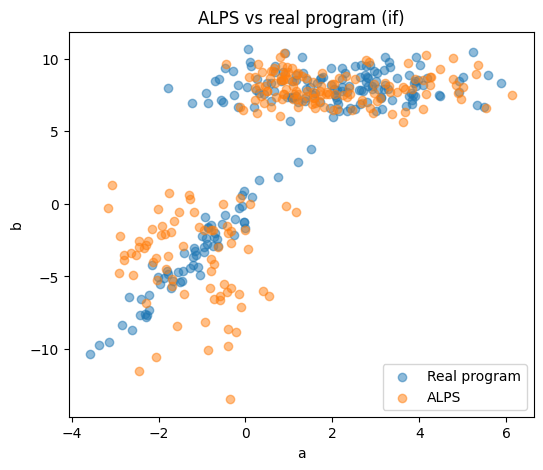

if / RS-Grad: NLL=5.0914


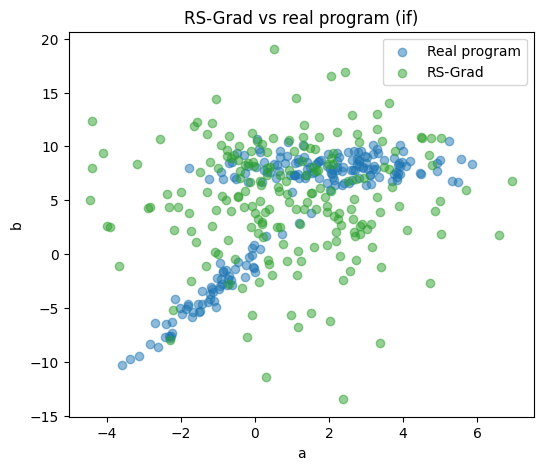

if / RS-MCMC: NLL=4.5148


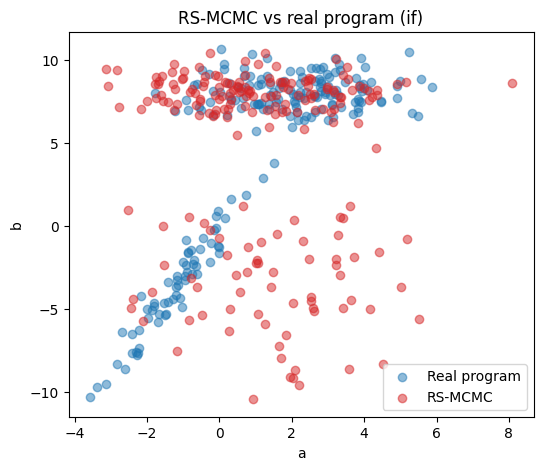

if / MCMC: NLL=5.2305


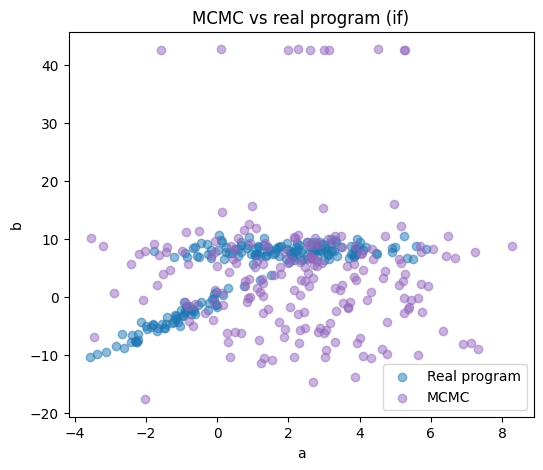

if / Evolutionary: NLL=4.8114


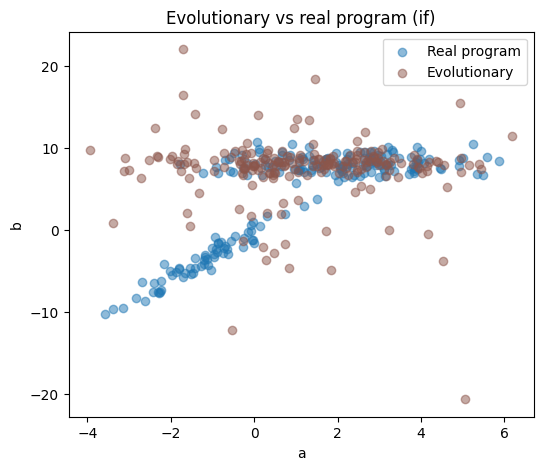

In [3]:
program = "if"
var_names = get_var_names(program)
data = get_dataset(program, EVAL_DATA_SIZE)
real_code = get_real_programs(program)
real_cfg = produce_cfg_text(compile2SOGA_text(real_code))
smooth_cfg(real_cfg)
real_dist = start_SOGA(real_cfg)
real_samples = sample_ordered(real_dist, N_SAMPLES, var_names)

for method in LOCAL_METHODS:
    best = best_local_candidate(program, method, var_names, data)
    label = METHOD_LABELS[method]
    if best is None:
        print(f"{program} / {label}: NO VALID CANDIDATE")
        continue
    nll, dist = best
    print(f"{program} / {label}: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
               f"{label} vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
                   f"{label} vs real program ({program}), 3D")

best_evo = best_evolutionary_candidate(program, var_names, data)
if best_evo is None:
    print(f"{program} / Evolutionary: NO VALID CANDIDATE")
else:
    nll, dist = best_evo
    print(f"{program} / Evolutionary: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
               f"Evolutionary vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
                   f"Evolutionary vs real program ({program}), 3D")


## mog1

line 1:628 mismatched input '<EOF>' expecting 'end if'


mog1 / ALPS: NLL=6.4272


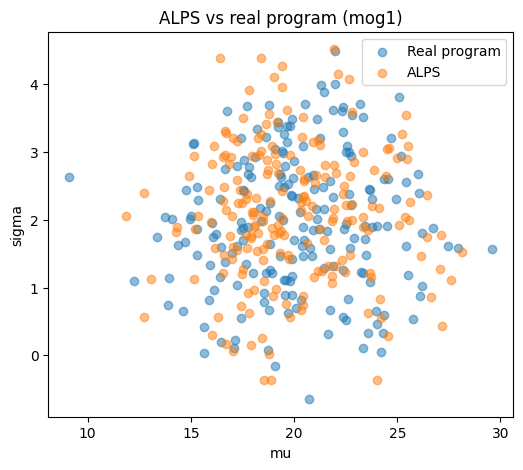

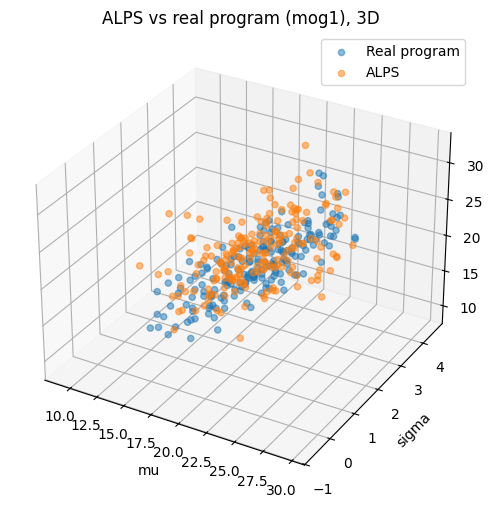

mog1 / RS-Grad: NLL=6.7108


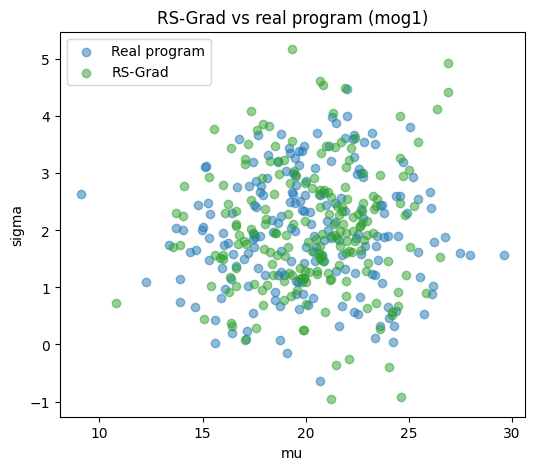

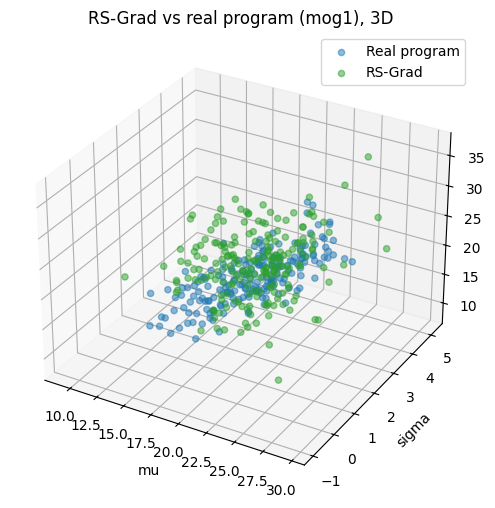

mog1 / RS-MCMC: NLL=6.7124


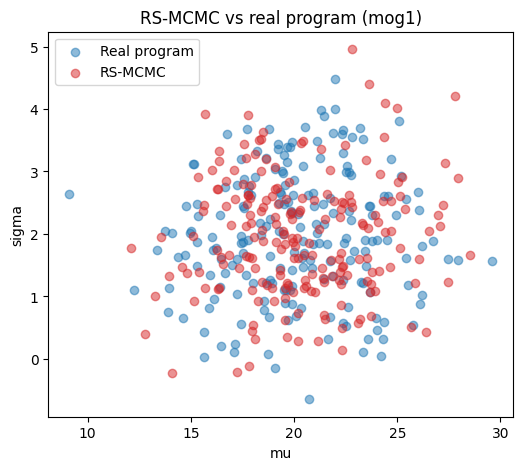

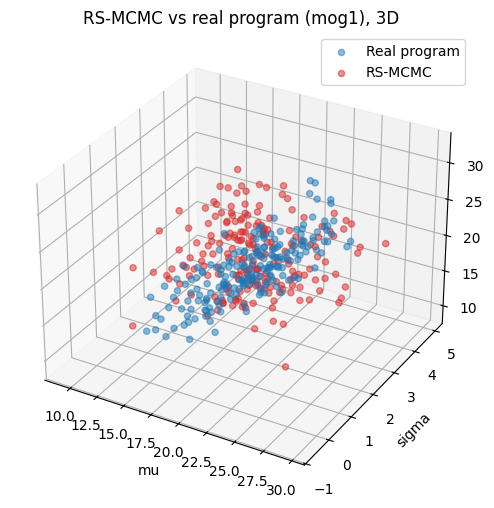

mog1 / MCMC: NLL=6.8289


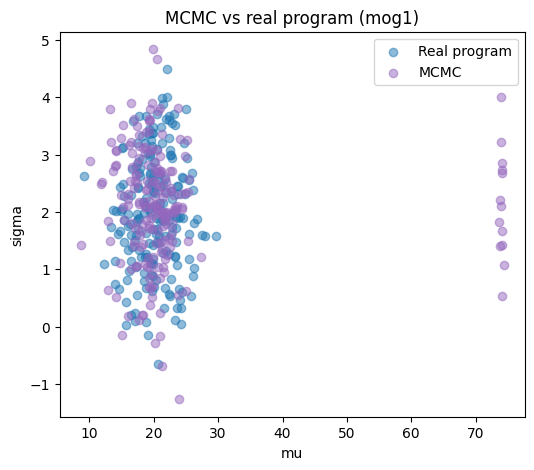

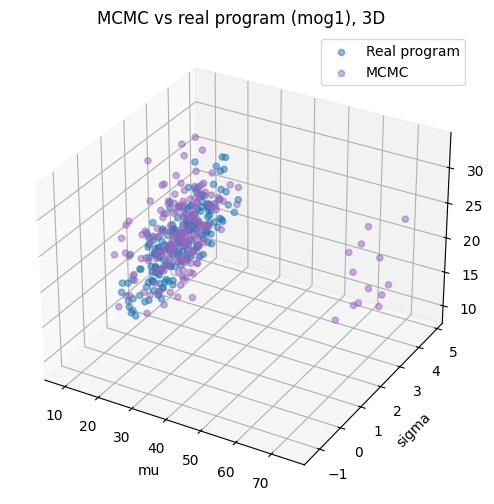

Degeneracy in if condition detected. Please smooth the program.


mog1 / Evolutionary: NLL=6.6483


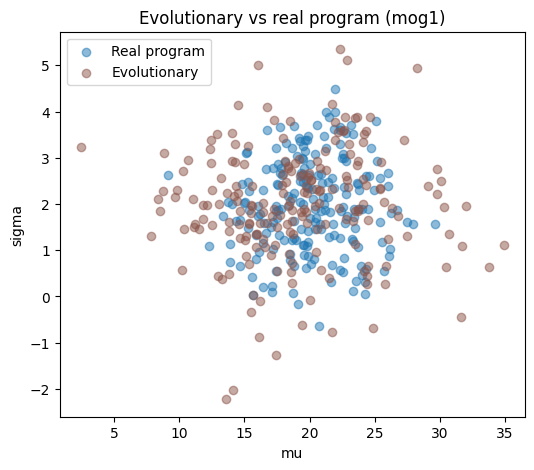

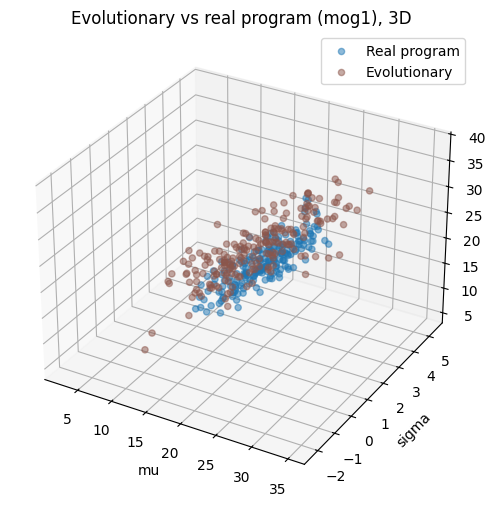

In [4]:
program = "mog1"
var_names = get_var_names(program)
data = get_dataset(program, EVAL_DATA_SIZE)
real_code = get_real_programs(program)
real_cfg = produce_cfg_text(compile2SOGA_text(real_code))
smooth_cfg(real_cfg)
real_dist = start_SOGA(real_cfg)
real_samples = sample_ordered(real_dist, N_SAMPLES, var_names)

for method in LOCAL_METHODS:
    best = best_local_candidate(program, method, var_names, data)
    label = METHOD_LABELS[method]
    if best is None:
        print(f"{program} / {label}: NO VALID CANDIDATE")
        continue
    nll, dist = best
    print(f"{program} / {label}: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
               f"{label} vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
                   f"{label} vs real program ({program}), 3D")

best_evo = best_evolutionary_candidate(program, var_names, data)
if best_evo is None:
    print(f"{program} / Evolutionary: NO VALID CANDIDATE")
else:
    nll, dist = best_evo
    print(f"{program} / Evolutionary: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
               f"Evolutionary vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
                   f"Evolutionary vs real program ({program}), 3D")


## csi

csi / ALPS: NLL=-21.3755


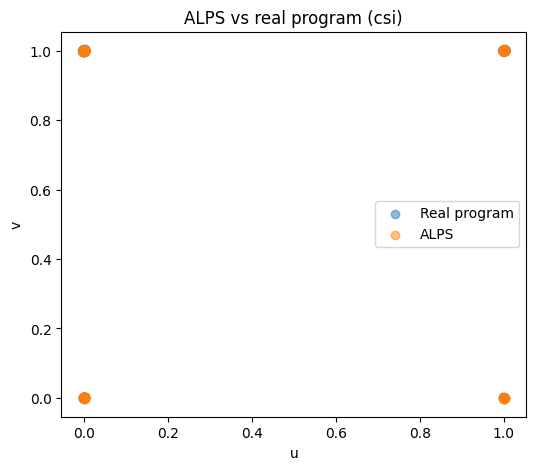

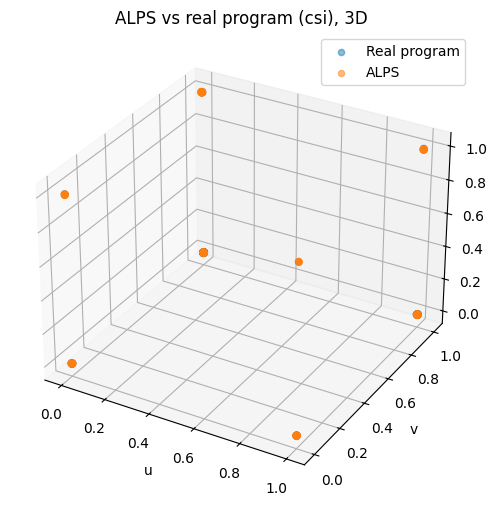

csi / RS-Grad: NLL=1.7731


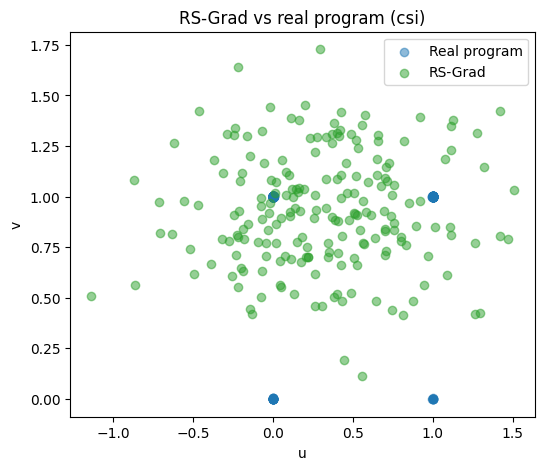

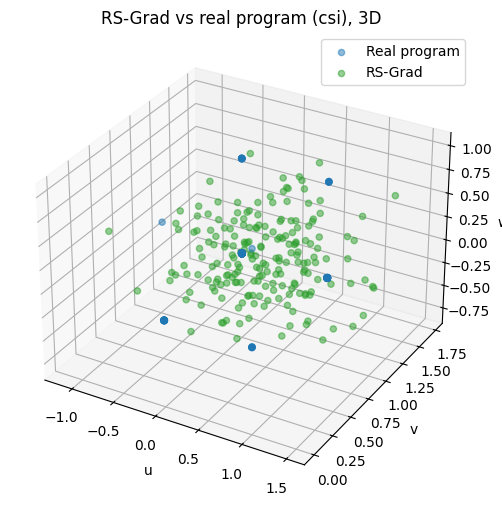

csi / RS-MCMC: NLL=1.7769


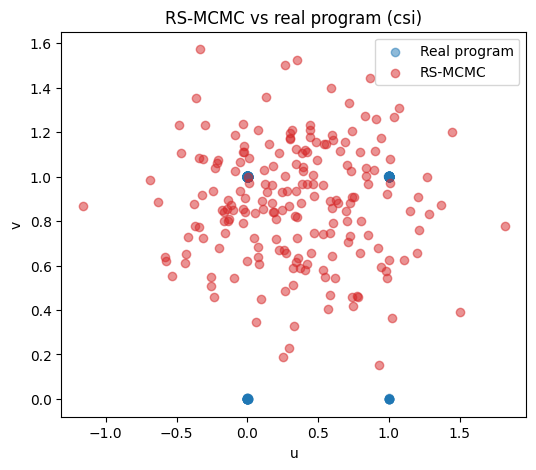

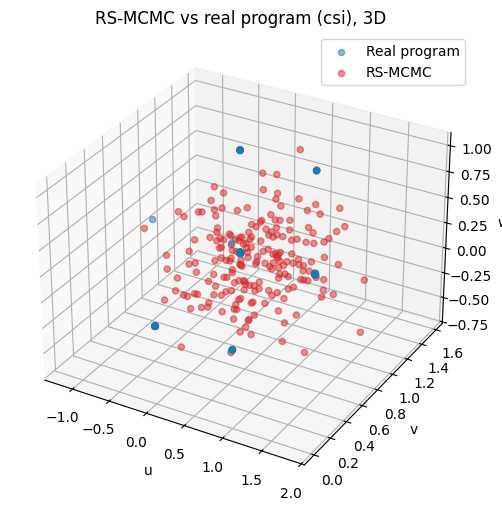

csi / MCMC: NLL=2.4431


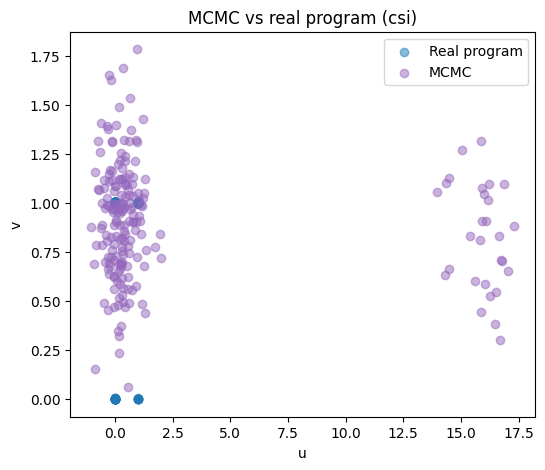

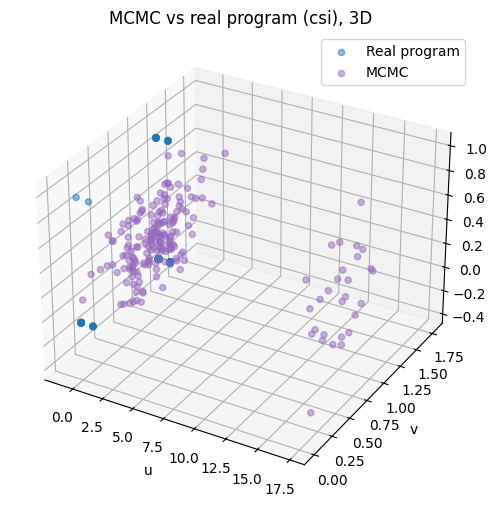

csi / Evolutionary: NLL=-21.9269


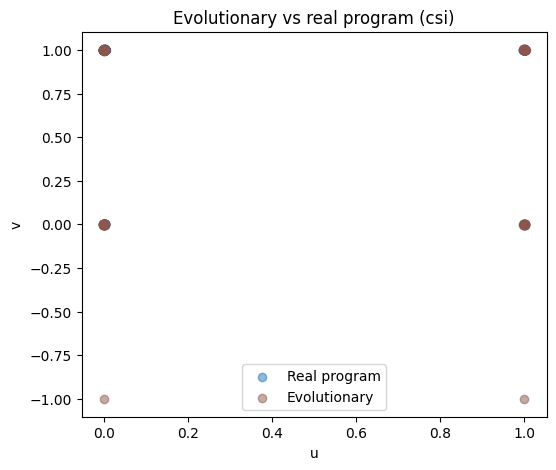

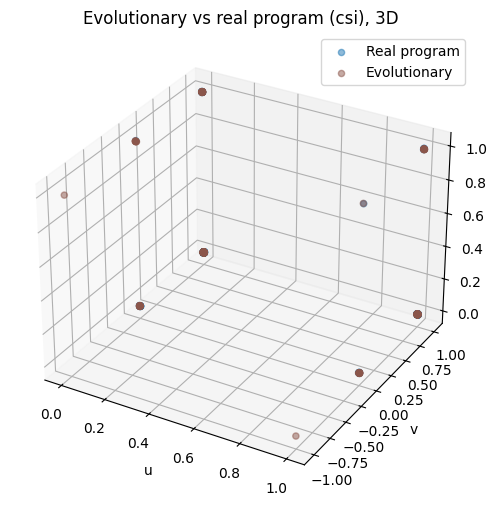

In [5]:
program = "csi"
var_names = get_var_names(program)
data = get_dataset(program, EVAL_DATA_SIZE)
real_code = get_real_programs(program)
real_cfg = produce_cfg_text(compile2SOGA_text(real_code))
smooth_cfg(real_cfg)
real_dist = start_SOGA(real_cfg)
real_samples = sample_ordered(real_dist, N_SAMPLES, var_names)

for method in LOCAL_METHODS:
    best = best_local_candidate(program, method, var_names, data)
    label = METHOD_LABELS[method]
    if best is None:
        print(f"{program} / {label}: NO VALID CANDIDATE")
        continue
    nll, dist = best
    print(f"{program} / {label}: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
               f"{label} vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
                   f"{label} vs real program ({program}), 3D")

best_evo = best_evolutionary_candidate(program, var_names, data)
if best_evo is None:
    print(f"{program} / Evolutionary: NO VALID CANDIDATE")
else:
    nll, dist = best_evo
    print(f"{program} / Evolutionary: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
               f"Evolutionary vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
                   f"Evolutionary vs real program ({program}), 3D")


## easytugwar

line 1:946 mismatched input '}' expecting 'end if'
line 1:948 mismatched input '}' expecting 'end if'
line 1:1392 mismatched input '}' expecting 'end if'
line 1:1394 extraneous input '}' expecting 'end if'
line 1:1403 mismatched input '<EOF>' expecting '}'


easytugwar / ALPS: NLL=0.0158


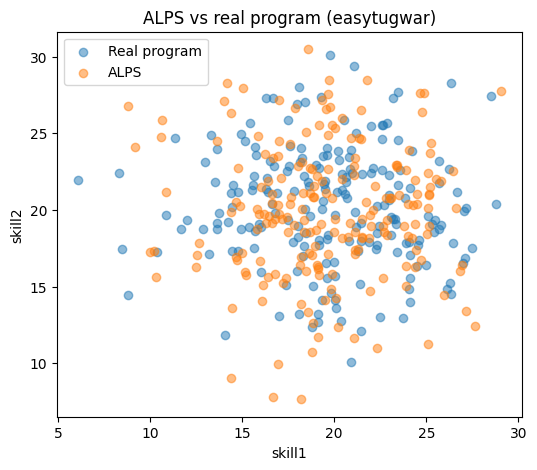

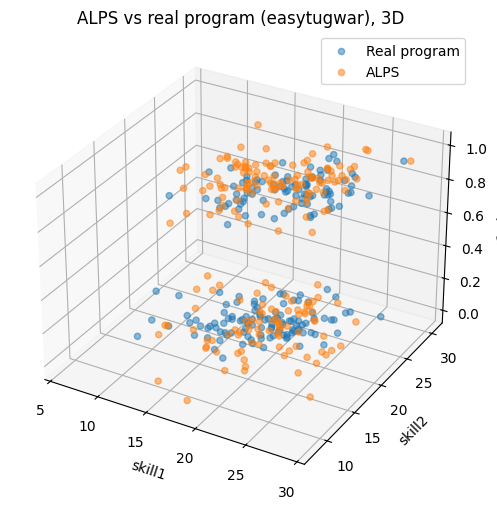

easytugwar / RS-Grad: NLL=2.9130


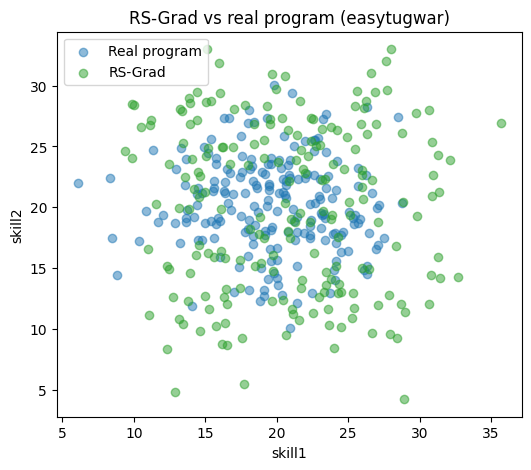

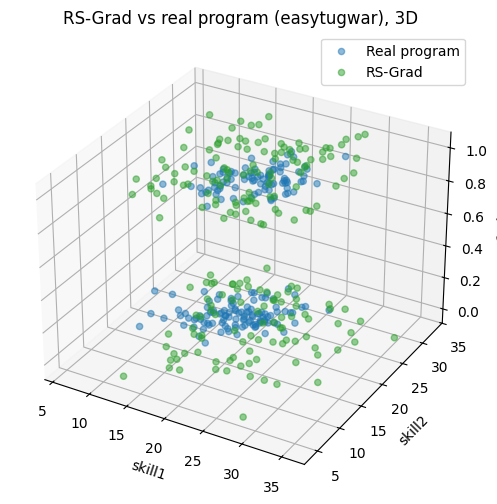

easytugwar / RS-MCMC: NLL=6.3442


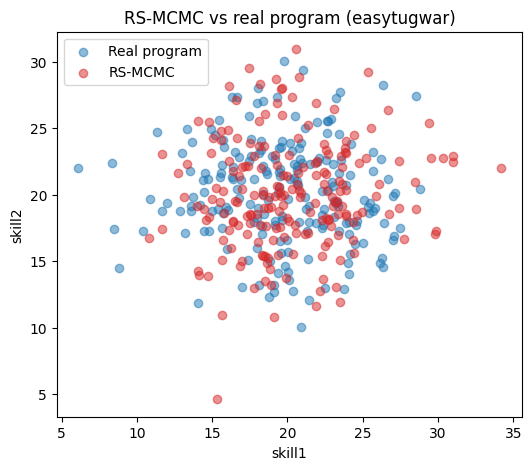

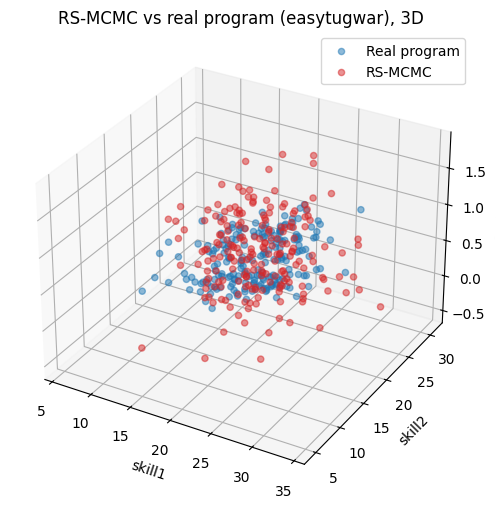

easytugwar / MCMC: NLL=6.7426


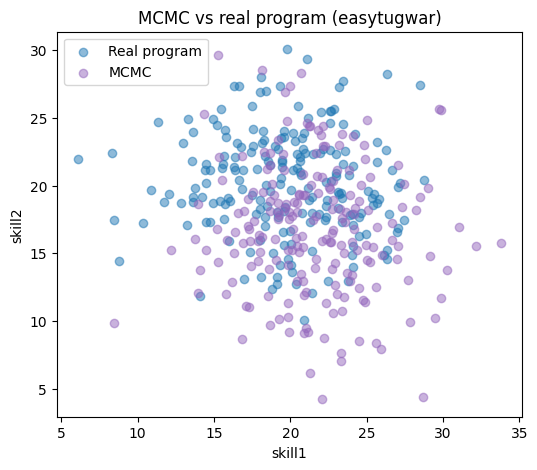

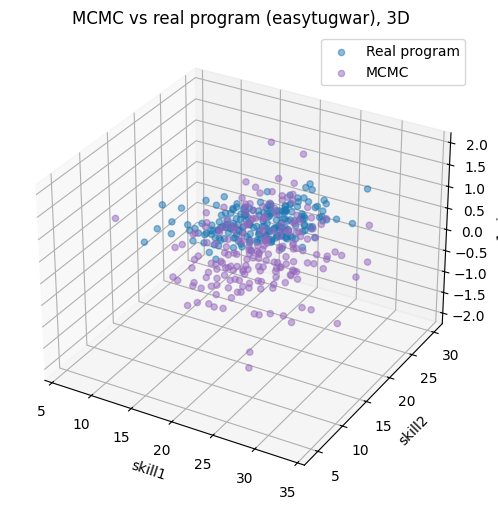

Degeneracy in if condition detected. Please smooth the program.


easytugwar / Evolutionary: NLL=0.3327


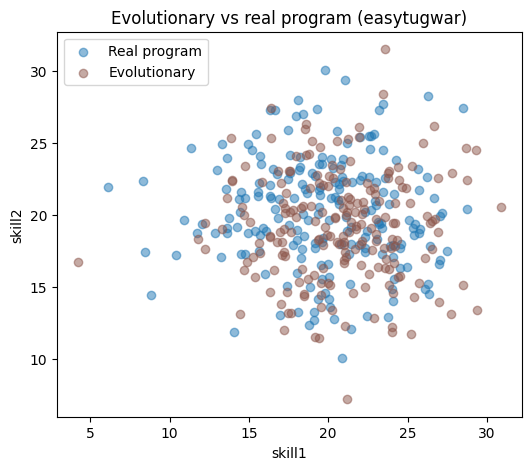

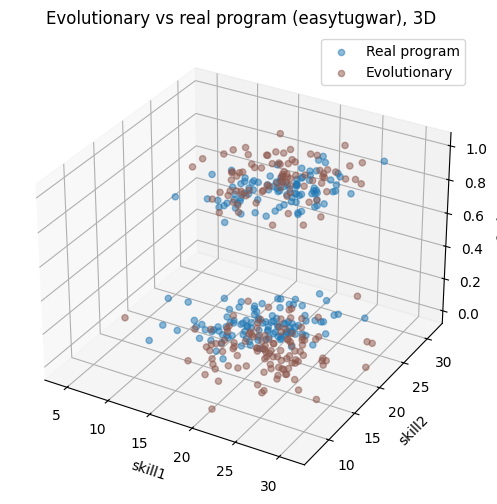

In [6]:
program = "easytugwar"
var_names = get_var_names(program)
data = get_dataset(program, EVAL_DATA_SIZE)
real_code = get_real_programs(program)
real_cfg = produce_cfg_text(compile2SOGA_text(real_code))
smooth_cfg(real_cfg)
real_dist = start_SOGA(real_cfg)
real_samples = sample_ordered(real_dist, N_SAMPLES, var_names)

for method in LOCAL_METHODS:
    best = best_local_candidate(program, method, var_names, data)
    label = METHOD_LABELS[method]
    if best is None:
        print(f"{program} / {label}: NO VALID CANDIDATE")
        continue
    nll, dist = best
    print(f"{program} / {label}: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
               f"{label} vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
                   f"{label} vs real program ({program}), 3D")

best_evo = best_evolutionary_candidate(program, var_names, data)
if best_evo is None:
    print(f"{program} / Evolutionary: NO VALID CANDIDATE")
else:
    nll, dist = best_evo
    print(f"{program} / Evolutionary: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
               f"Evolutionary vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
                   f"Evolutionary vs real program ({program}), 3D")


## biasedtugwar

biasedtugwar / ALPS: NLL=0.0891


line 5:0 missing ';' at '}'
line 7:0 missing ';' at '}'


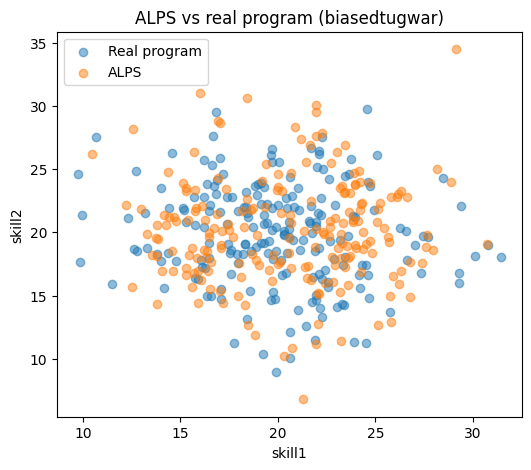

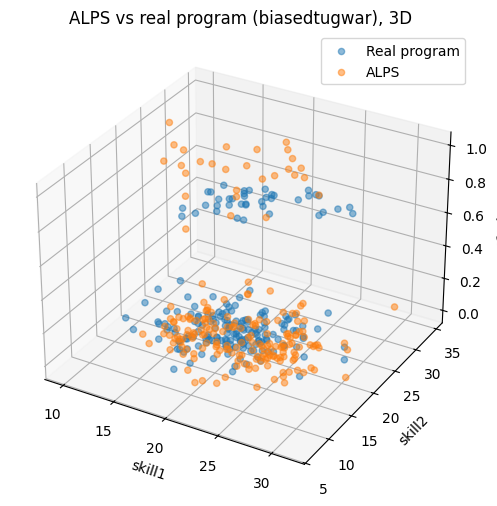

biasedtugwar / RS-Grad: NLL=3.4529


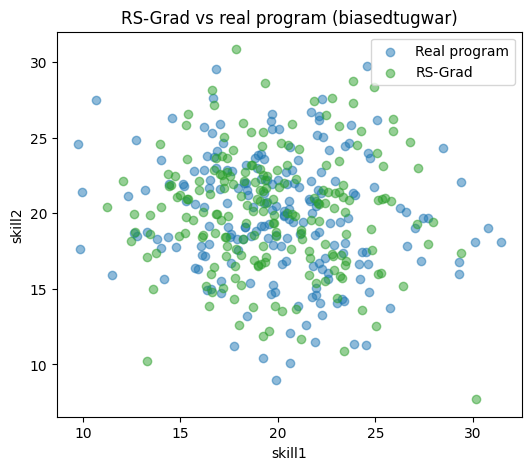

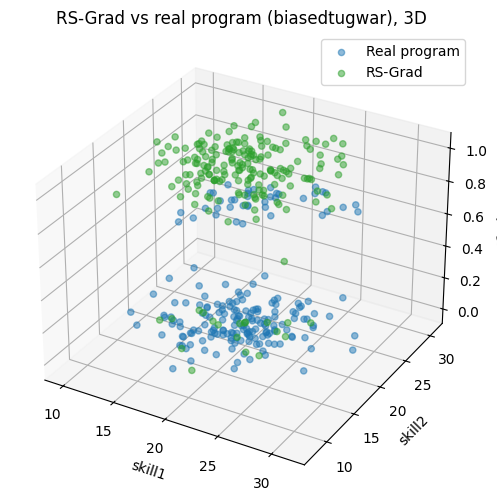

biasedtugwar / RS-MCMC: NLL=6.0832


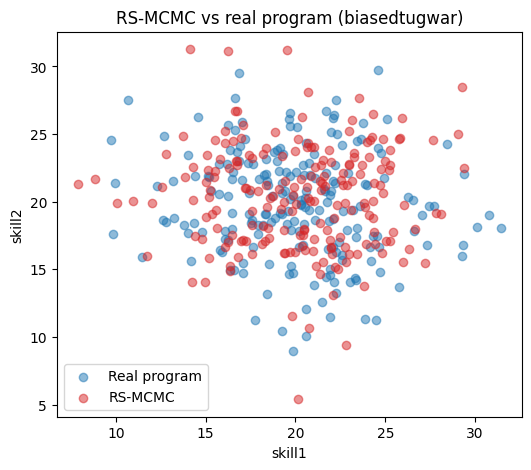

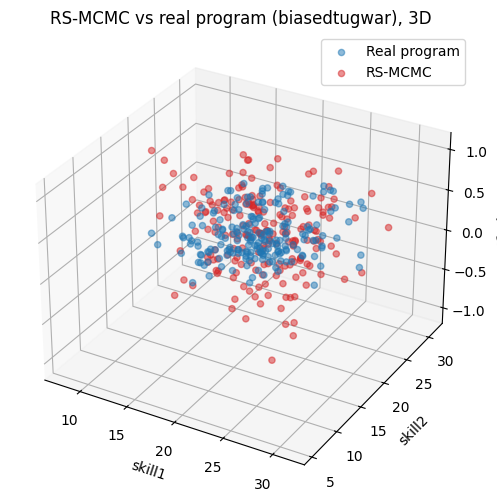

biasedtugwar / MCMC: NLL=5.8735


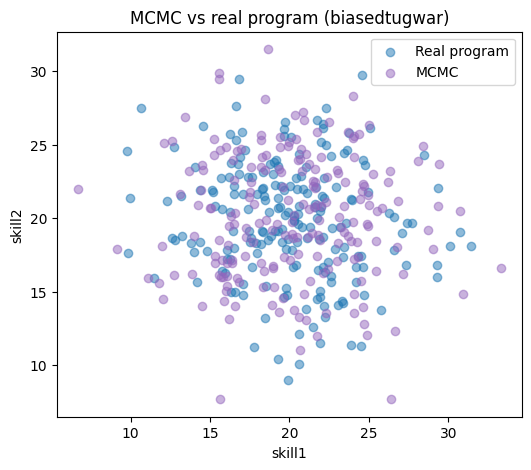

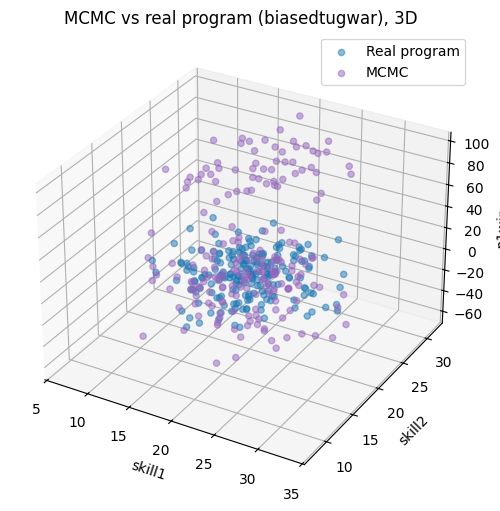

Degeneracy in if condition detected. Please smooth the program.


Degeneracy in if condition detected. Please smooth the program.


Degeneracy in if condition detected. Please smooth the program.


Degeneracy in if condition detected. Please smooth the program.


Degeneracy in if condition detected. Please smooth the program.


biasedtugwar / Evolutionary: NLL=0.1272


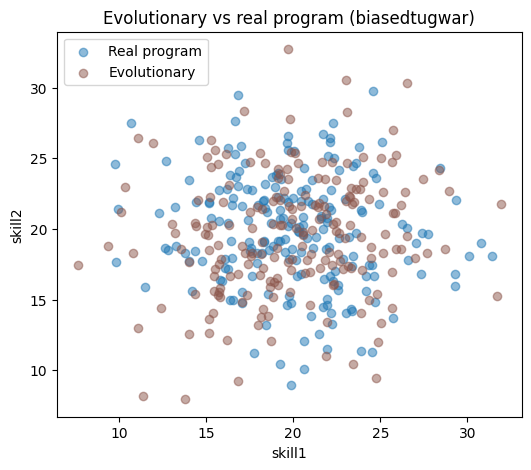

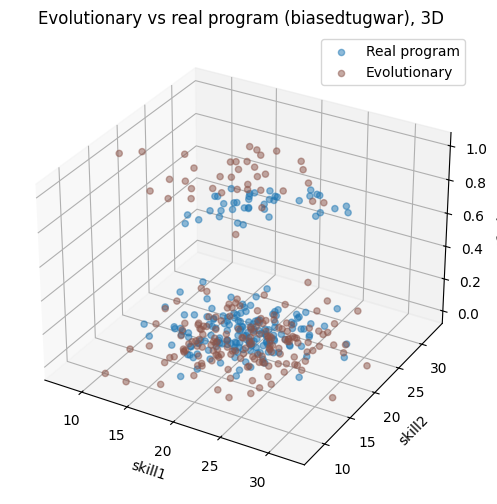

In [7]:
program = "biasedtugwar"
var_names = get_var_names(program)
data = get_dataset(program, EVAL_DATA_SIZE)
real_code = get_real_programs(program)
real_cfg = produce_cfg_text(compile2SOGA_text(real_code))
smooth_cfg(real_cfg)
real_dist = start_SOGA(real_cfg)
real_samples = sample_ordered(real_dist, N_SAMPLES, var_names)

for method in LOCAL_METHODS:
    best = best_local_candidate(program, method, var_names, data)
    label = METHOD_LABELS[method]
    if best is None:
        print(f"{program} / {label}: NO VALID CANDIDATE")
        continue
    nll, dist = best
    print(f"{program} / {label}: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
               f"{label} vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
                   f"{label} vs real program ({program}), 3D")

best_evo = best_evolutionary_candidate(program, var_names, data)
if best_evo is None:
    print(f"{program} / Evolutionary: NO VALID CANDIDATE")
else:
    nll, dist = best_evo
    print(f"{program} / Evolutionary: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
               f"Evolutionary vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
                   f"Evolutionary vs real program ({program}), 3D")


## mixedcondition

mixedcondition / ALPS: NLL=-0.9380


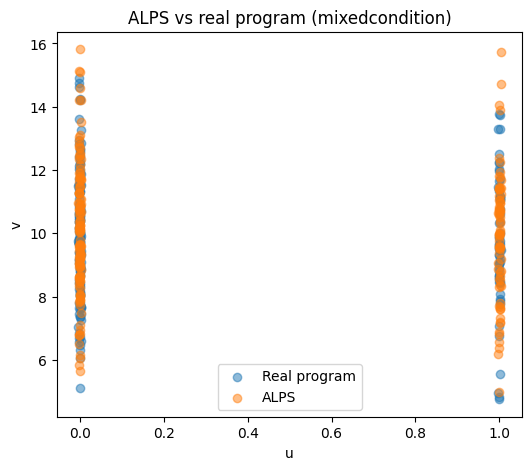

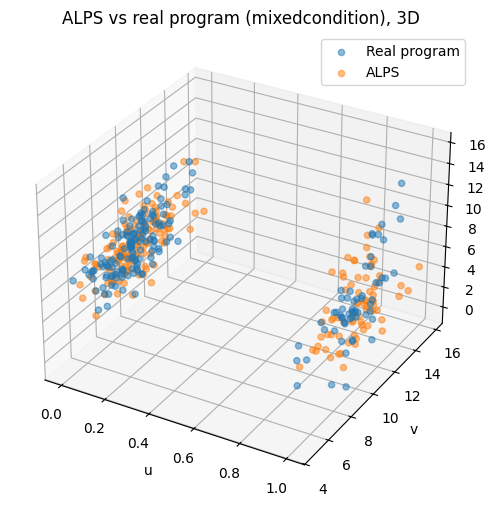

mixedcondition / RS-Grad: NLL=1.2717


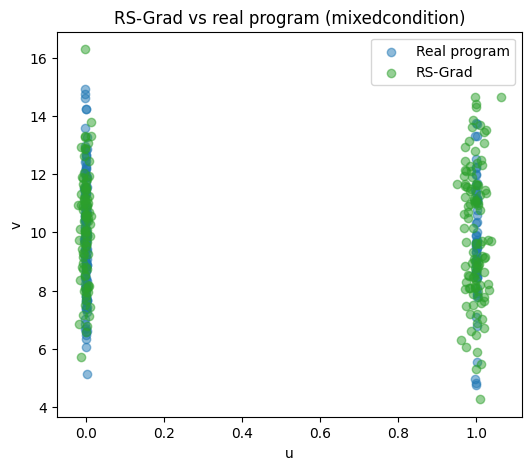

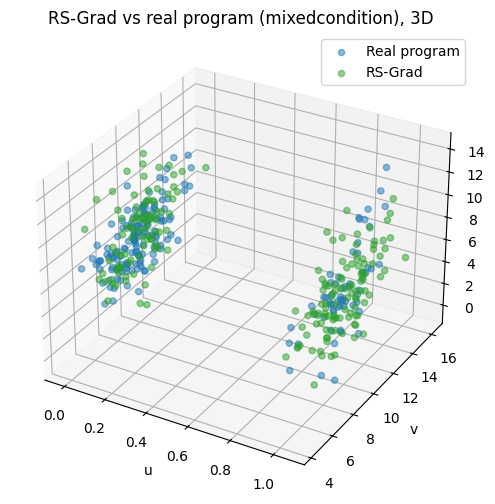

mixedcondition / RS-MCMC: NLL=5.0305


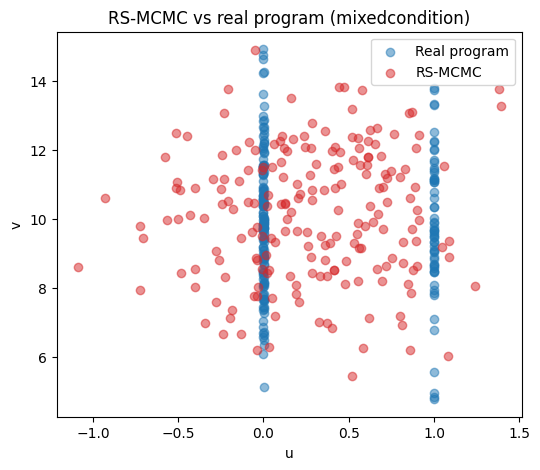

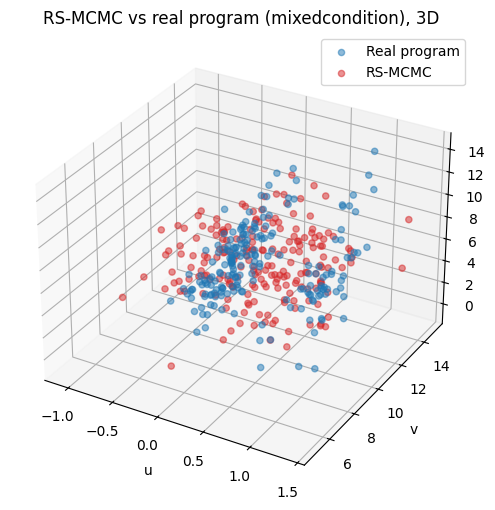

mixedcondition / MCMC: NLL=5.6046


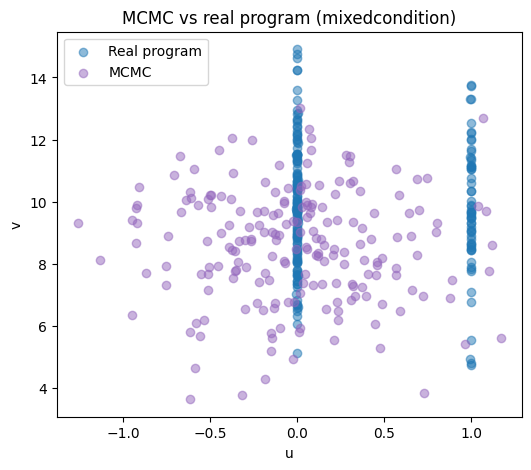

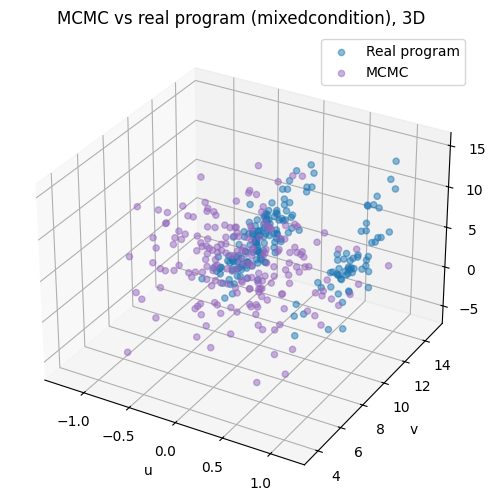

Degeneracy in if condition detected. Please smooth the program.


Degeneracy in if condition detected. Please smooth the program.


mixedcondition / Evolutionary: NLL=-0.8816


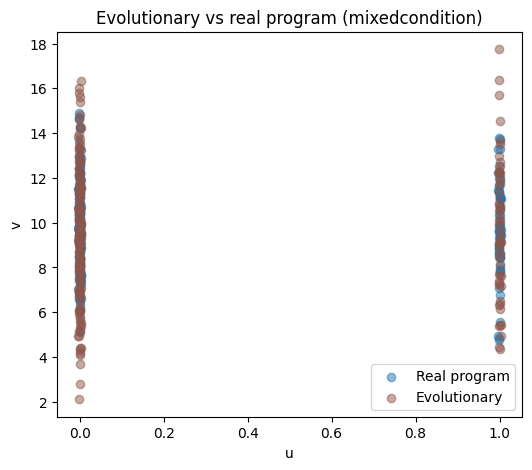

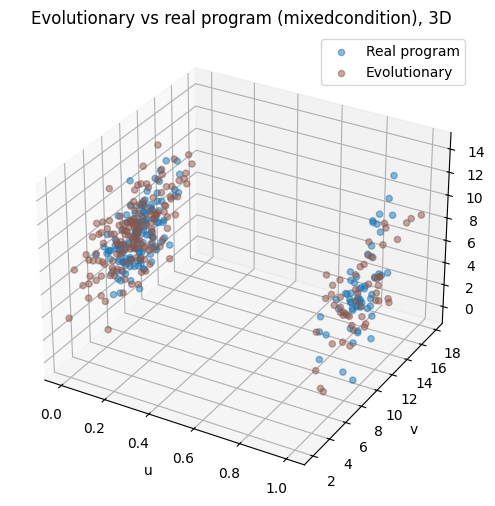

In [8]:
program = "mixedcondition"
var_names = get_var_names(program)
data = get_dataset(program, EVAL_DATA_SIZE)
real_code = get_real_programs(program)
real_cfg = produce_cfg_text(compile2SOGA_text(real_code))
smooth_cfg(real_cfg)
real_dist = start_SOGA(real_cfg)
real_samples = sample_ordered(real_dist, N_SAMPLES, var_names)

for method in LOCAL_METHODS:
    best = best_local_candidate(program, method, var_names, data)
    label = METHOD_LABELS[method]
    if best is None:
        print(f"{program} / {label}: NO VALID CANDIDATE")
        continue
    nll, dist = best
    print(f"{program} / {label}: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
               f"{label} vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
                   f"{label} vs real program ({program}), 3D")

best_evo = best_evolutionary_candidate(program, var_names, data)
if best_evo is None:
    print(f"{program} / Evolutionary: NO VALID CANDIDATE")
else:
    nll, dist = best_evo
    print(f"{program} / Evolutionary: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
               f"Evolutionary vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
                   f"Evolutionary vs real program ({program}), 3D")


## multiplebranches

multiplebranches / ALPS: NLL=5.7666


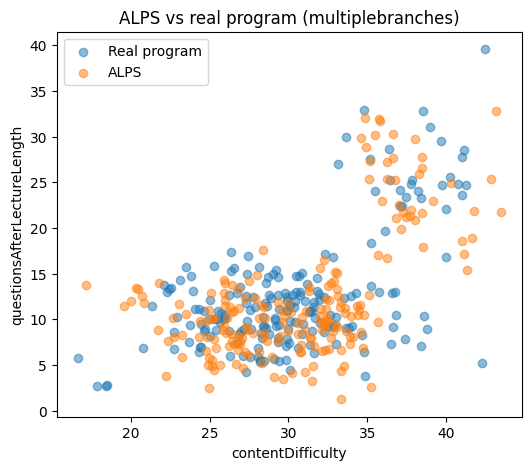

multiplebranches / RS-Grad: NLL=6.1429


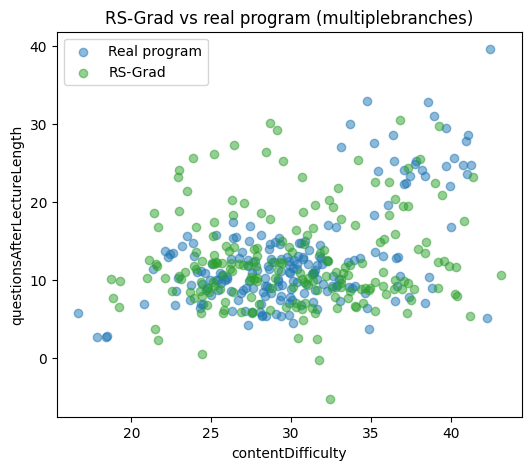

multiplebranches / RS-MCMC: NLL=6.1016


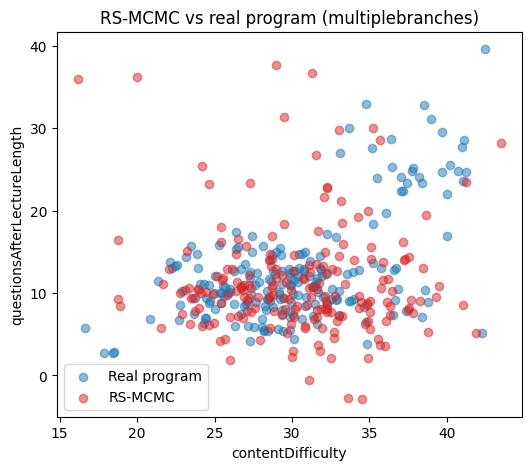

multiplebranches / MCMC: NLL=6.2338


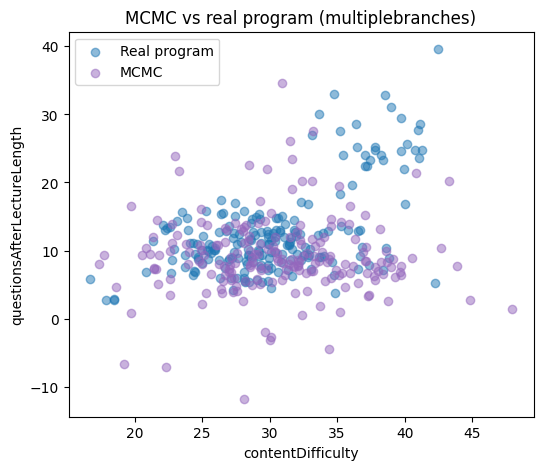

Degeneracy in if condition detected. Please smooth the program.


multiplebranches / Evolutionary: NLL=6.1548


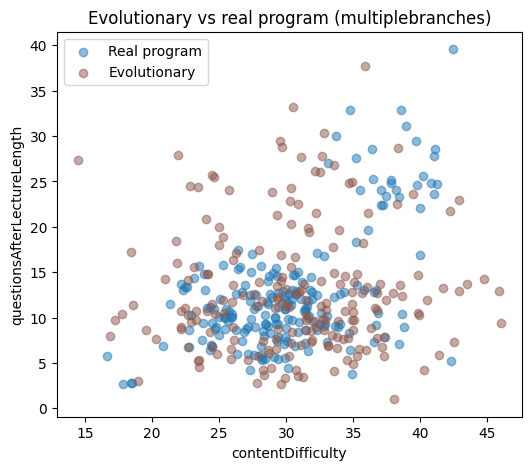

In [9]:
program = "multiplebranches"
var_names = get_var_names(program)
data = get_dataset(program, EVAL_DATA_SIZE)
real_code = get_real_programs(program)
real_cfg = produce_cfg_text(compile2SOGA_text(real_code))
smooth_cfg(real_cfg)
real_dist = start_SOGA(real_cfg)
real_samples = sample_ordered(real_dist, N_SAMPLES, var_names)

for method in LOCAL_METHODS:
    best = best_local_candidate(program, method, var_names, data)
    label = METHOD_LABELS[method]
    if best is None:
        print(f"{program} / {label}: NO VALID CANDIDATE")
        continue
    nll, dist = best
    print(f"{program} / {label}: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
               f"{label} vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
                   f"{label} vs real program ({program}), 3D")

best_evo = best_evolutionary_candidate(program, var_names, data)
if best_evo is None:
    print(f"{program} / Evolutionary: NO VALID CANDIDATE")
else:
    nll, dist = best_evo
    print(f"{program} / Evolutionary: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
               f"Evolutionary vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
                   f"Evolutionary vs real program ({program}), 3D")


## eyecolor

eyecolor / ALPS: NLL=-13.6459


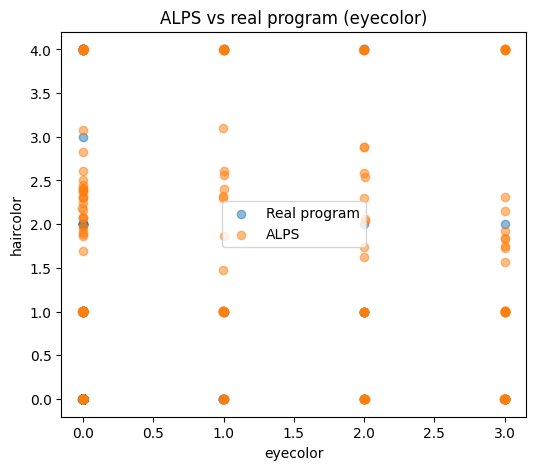

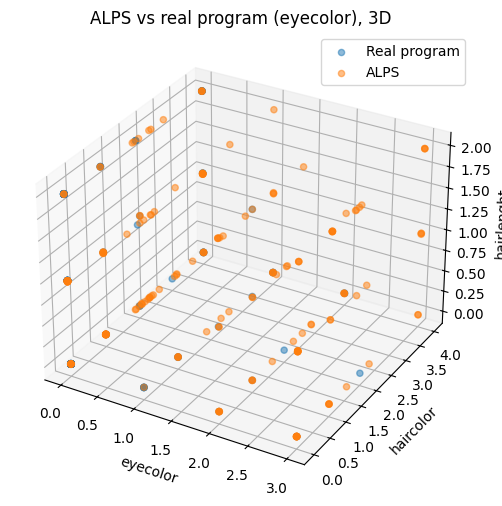

eyecolor / RS-Grad: NLL=2.0815


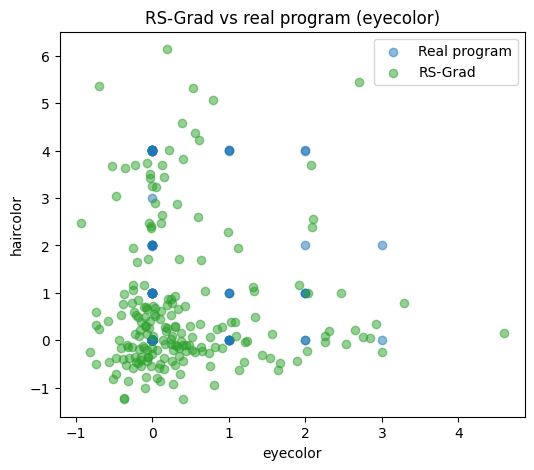

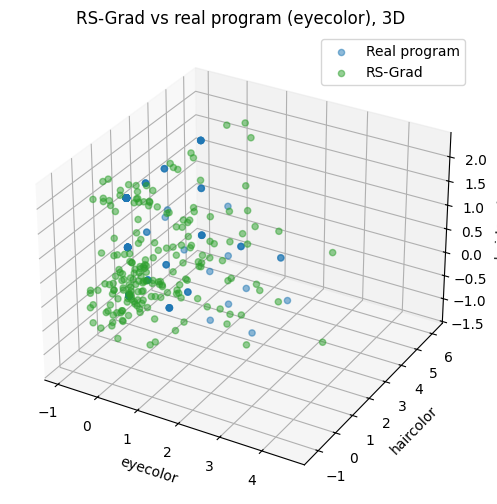

eyecolor / RS-MCMC: NLL=3.7157


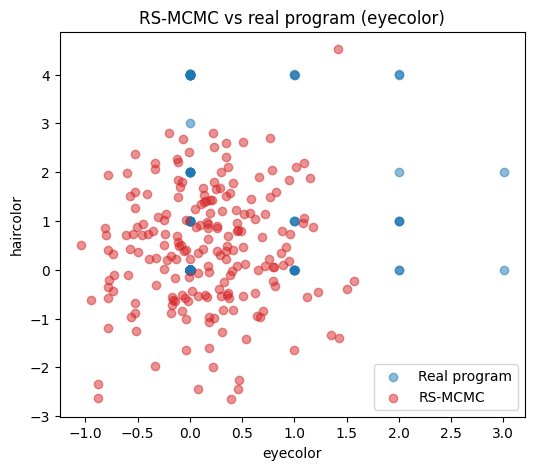

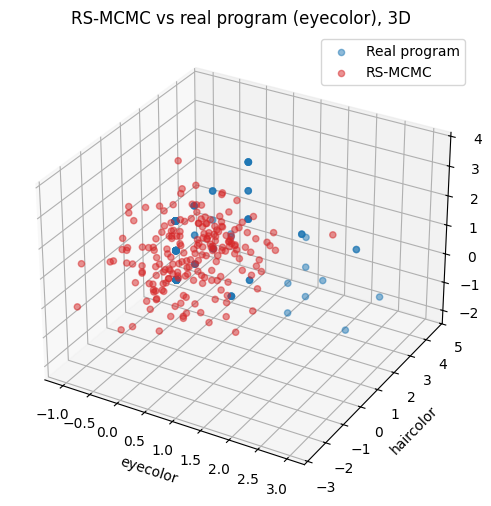

eyecolor / MCMC: NLL=3.0877


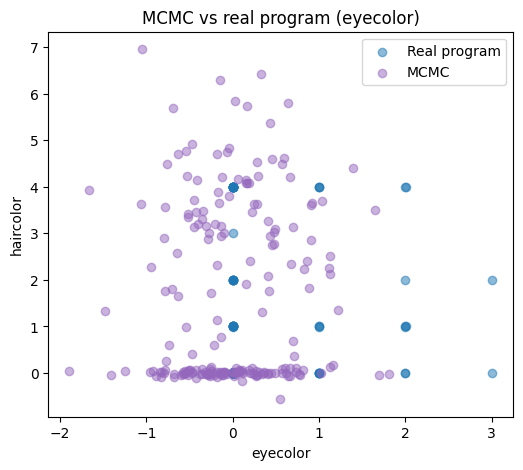

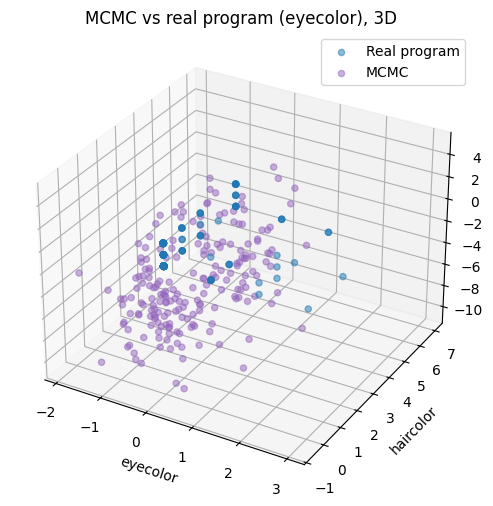

Degeneracy in if condition detected. Please smooth the program.


eyecolor / Evolutionary: NLL=-15.0801


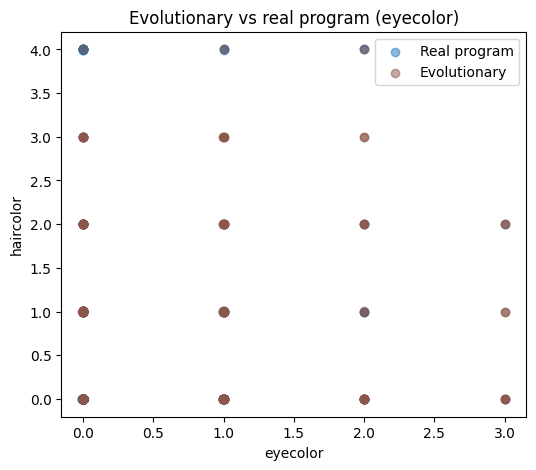

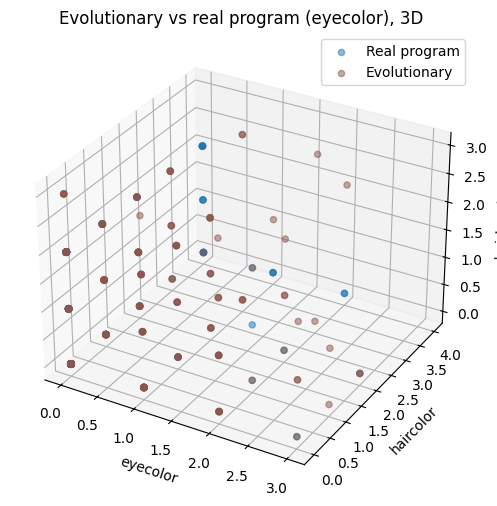

In [10]:
program = "eyecolor"
var_names = get_var_names(program)
data = get_dataset(program, EVAL_DATA_SIZE)
real_code = get_real_programs(program)
real_cfg = produce_cfg_text(compile2SOGA_text(real_code))
smooth_cfg(real_cfg)
real_dist = start_SOGA(real_cfg)
real_samples = sample_ordered(real_dist, N_SAMPLES, var_names)

for method in LOCAL_METHODS:
    best = best_local_candidate(program, method, var_names, data)
    label = METHOD_LABELS[method]
    if best is None:
        print(f"{program} / {label}: NO VALID CANDIDATE")
        continue
    nll, dist = best
    print(f"{program} / {label}: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
               f"{label} vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
                   f"{label} vs real program ({program}), 3D")

best_evo = best_evolutionary_candidate(program, var_names, data)
if best_evo is None:
    print(f"{program} / Evolutionary: NO VALID CANDIDATE")
else:
    nll, dist = best_evo
    print(f"{program} / Evolutionary: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
               f"Evolutionary vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
                   f"Evolutionary vs real program ({program}), 3D")


## hurricane

hurricane / ALPS: NLL=-10.0855


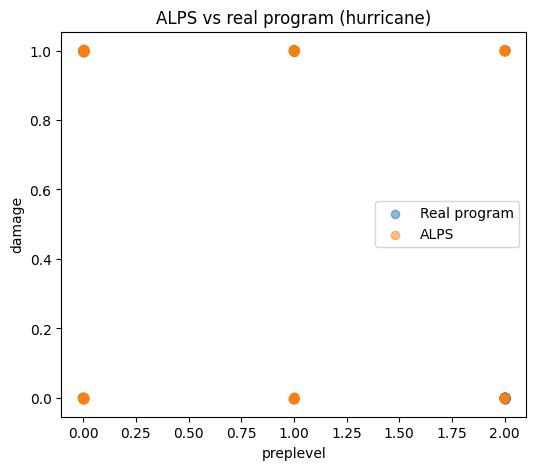

hurricane / RS-Grad: NLL=-0.1009


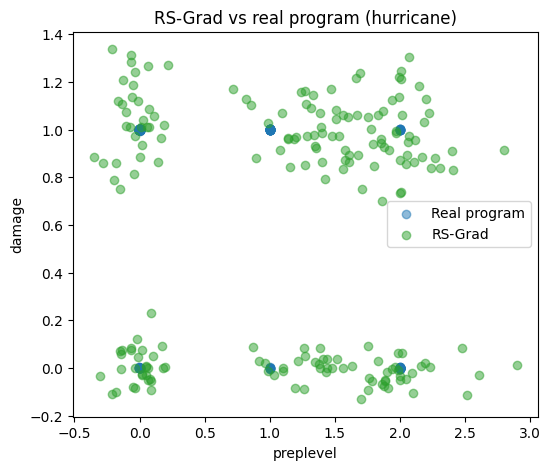

hurricane / RS-MCMC: NLL=-7.2570


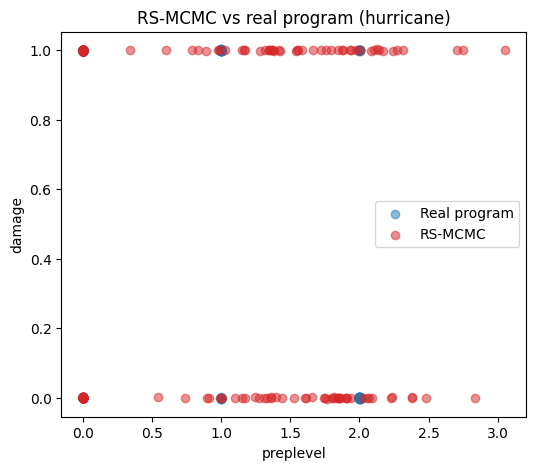

hurricane / MCMC: NLL=2.3484


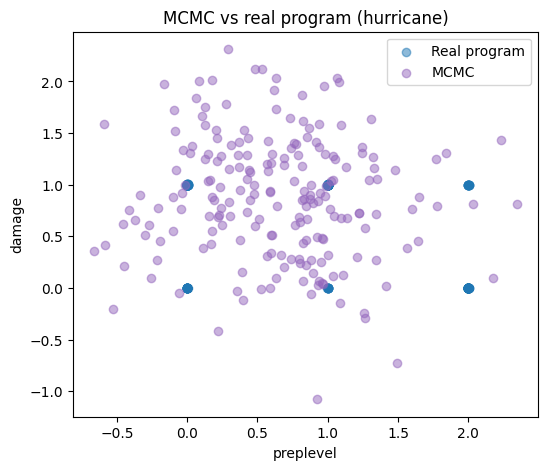

Degeneracy in if condition detected. Please smooth the program.


Degeneracy in if condition detected. Please smooth the program.


hurricane / Evolutionary: NLL=-10.2789


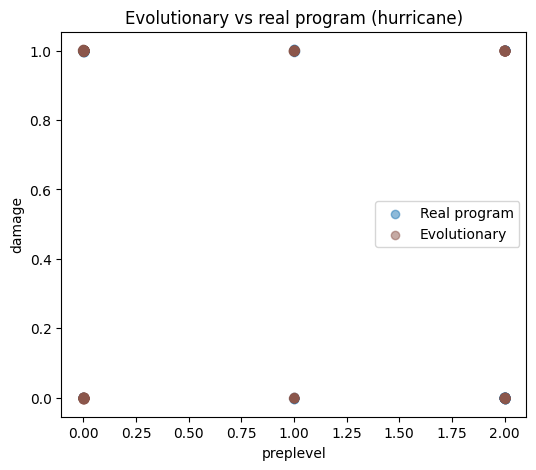

In [11]:
program = "hurricane"
var_names = get_var_names(program)
data = get_dataset(program, EVAL_DATA_SIZE)
real_code = get_real_programs(program)
real_cfg = produce_cfg_text(compile2SOGA_text(real_code))
smooth_cfg(real_cfg)
real_dist = start_SOGA(real_cfg)
real_samples = sample_ordered(real_dist, N_SAMPLES, var_names)

for method in LOCAL_METHODS:
    best = best_local_candidate(program, method, var_names, data)
    label = METHOD_LABELS[method]
    if best is None:
        print(f"{program} / {label}: NO VALID CANDIDATE")
        continue
    nll, dist = best
    print(f"{program} / {label}: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
               f"{label} vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, label, METHOD_COLORS[method],
                   f"{label} vs real program ({program}), 3D")

best_evo = best_evolutionary_candidate(program, var_names, data)
if best_evo is None:
    print(f"{program} / Evolutionary: NO VALID CANDIDATE")
else:
    nll, dist = best_evo
    print(f"{program} / Evolutionary: NLL={nll:.4f}")
    cand_samples = sample_ordered(dist, N_SAMPLES, var_names)
    scatter_2d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
               f"Evolutionary vs real program ({program})")
    if len(var_names) > 2:
        scatter_3d(real_samples, cand_samples, var_names, "Evolutionary", METHOD_COLORS["Evolutionary"],
                   f"Evolutionary vs real program ({program}), 3D")
